<a href="https://colab.research.google.com/github/Diego-Alanis/INTELIGENCIA-ARTIFICIAL/blob/main/AF8_RNC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 8: Redes Neuronales Convolucionales
# Nombre: Diego Alanis
# Matrícula: 1959092
# Horario de clase: V6

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

In [3]:
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

print("Forma de los datos de entrenamiento:", train_data.shape)
print("Forma de las etiquetas de entrenamiento:", train_labels.shape)
print("Forma de los datos de prueba:", test_data.shape)
print("Forma de las etiquetas de prueba:", test_labels.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Forma de los datos de entrenamiento: (60000, 28, 28)
Forma de las etiquetas de entrenamiento: (60000,)
Forma de los datos de prueba: (10000, 28, 28)
Forma de las etiquetas de prueba: (10000,)


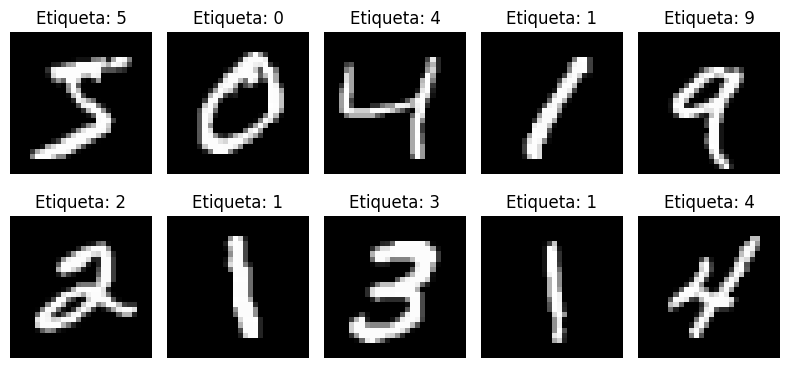

In [4]:
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_data[i], cmap="gray")
    plt.title(f"Etiqueta: {train_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# Normalizar los valores de los píxeles de 0-255 a 0-1
train_data = train_data.astype("float32") / 255.0
test_data = test_data.astype("float32") / 255.0

# Agregar un canal de color.
# MNIST está en escala de grises, por eso el canal es 1.
train_data = train_data.reshape((train_data.shape[0], 28, 28, 1))
test_data = test_data.reshape((test_data.shape[0], 28, 28, 1))

print("Nueva forma de train_data:", train_data.shape)
print("Nueva forma de test_data:", test_data.shape)

Nueva forma de train_data: (60000, 28, 28, 1)
Nueva forma de test_data: (10000, 28, 28, 1)


In [6]:
model = keras.Sequential([
    layers.Conv2D(32, kernel_size=(3, 3), activation="relu", input_shape=(28, 28, 1)),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Conv2D(64, kernel_size=(3, 3), activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    train_data,
    train_labels,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 29ms/step - accuracy: 0.9948 - loss: 0.0157 - val_accuracy: 0.9891 - val_loss: 0.0379
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9959 - loss: 0.0121 - val_accuracy: 0.9891 - val_loss: 0.0443
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 29ms/step - accuracy: 0.9963 - loss: 0.0108 - val_accuracy: 0.9892 - val_loss: 0.0441
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 29ms/step - accuracy: 0.9967 - loss: 0.0088 - val_accuracy: 0.9887 - val_loss: 0.0445
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 31ms/step - accuracy: 0.9978 - loss: 0.0061 - val_accuracy: 0.9885 - val_loss: 0.0500


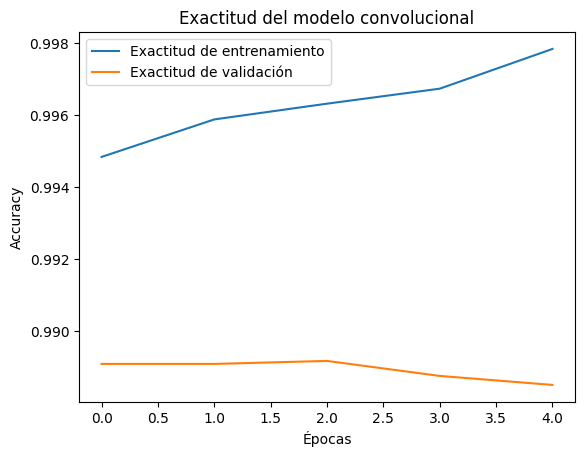

In [10]:
plt.plot(history.history["accuracy"], label="Exactitud de entrenamiento")
plt.plot(history.history["val_accuracy"], label="Exactitud de validación")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.title("Exactitud del modelo convolucional")
plt.legend()
plt.show()

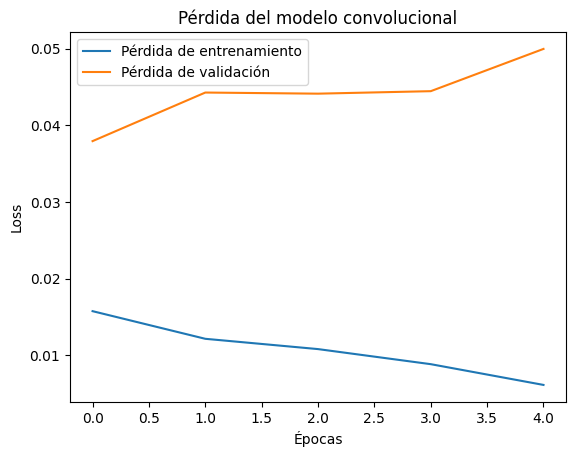

In [11]:
plt.plot(history.history["loss"], label="Pérdida de entrenamiento")
plt.plot(history.history["val_loss"], label="Pérdida de validación")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Pérdida del modelo convolucional")
plt.legend()
plt.show()

In [12]:
test_loss, test_accuracy = model.evaluate(test_data, test_labels)

print("Pérdida en datos de prueba:", test_loss)
print("Exactitud en datos de prueba:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9895 - loss: 0.0441
Pérdida en datos de prueba: 0.044112857431173325
Exactitud en datos de prueba: 0.9894999861717224


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step


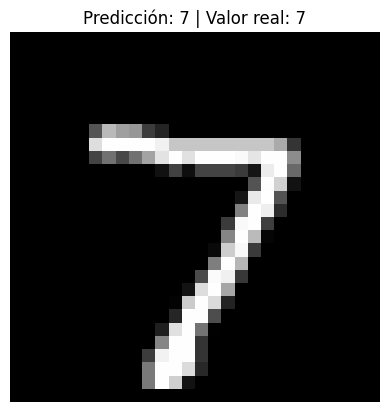

Imagen 1
Predicción del modelo: 7
Valor real: 7
-----------------------------------


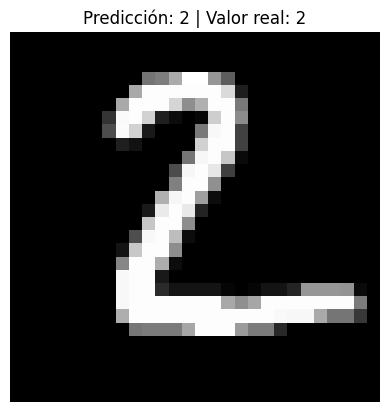

Imagen 2
Predicción del modelo: 2
Valor real: 2
-----------------------------------


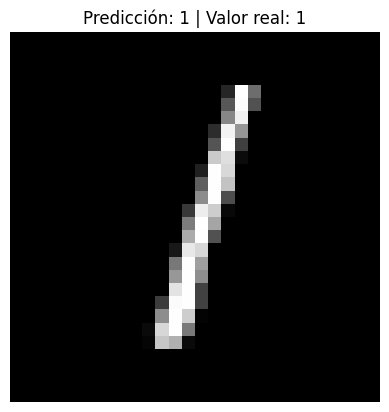

Imagen 3
Predicción del modelo: 1
Valor real: 1
-----------------------------------


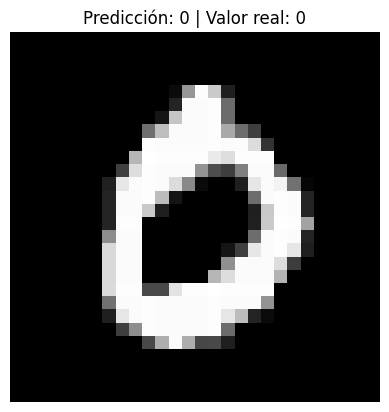

Imagen 4
Predicción del modelo: 0
Valor real: 0
-----------------------------------


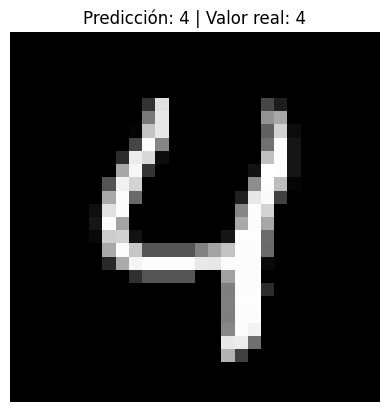

Imagen 5
Predicción del modelo: 4
Valor real: 4
-----------------------------------


In [13]:
predictions = model.predict(test_data)

for i in range(5):
    predicted_value = np.argmax(predictions[i])
    real_value = test_labels[i]

    plt.imshow(test_data[i].reshape(28, 28), cmap="gray")
    plt.title(f"Predicción: {predicted_value} | Valor real: {real_value}")
    plt.axis("off")
    plt.show()

    print("Imagen", i + 1)
    print("Predicción del modelo:", predicted_value)
    print("Valor real:", real_value)
    print("-----------------------------------")

In [14]:
print("Preguntas de la actividad")
print()
print("1. ¿Cuántas épocas usaste para mejorar el rendimiento del modelo en comparación con la red neuronal prealimentada de la actividad 5?")
print("Se utilizaron 5 épocas para entrenar el modelo convolucional. A pesar de usar menos épocas que una red neuronal prealimentada tradicional, el rendimiento fue alto debido a que las capas convolucionales extraen mejor las características visuales de las imágenes.")
print()
print("2. ¿Obtuviste un mejor rendimiento con este modelo o con el de la actividad 5? ¿Por qué?")
print("Se obtuvo un mejor rendimiento con la red neuronal convolucional, ya que este tipo de modelo está diseñado especialmente para trabajar con imágenes. Las capas convolucionales permiten detectar patrones como bordes, curvas y formas, lo cual ayuda a clasificar mejor los dígitos escritos a mano del conjunto MNIST.")

Preguntas de la actividad

1. ¿Cuántas épocas usaste para mejorar el rendimiento del modelo en comparación con la red neuronal prealimentada de la actividad 5?
Se utilizaron 5 épocas para entrenar el modelo convolucional. A pesar de usar menos épocas que una red neuronal prealimentada tradicional, el rendimiento fue alto debido a que las capas convolucionales extraen mejor las características visuales de las imágenes.

2. ¿Obtuviste un mejor rendimiento con este modelo o con el de la actividad 5? ¿Por qué?
Se obtuvo un mejor rendimiento con la red neuronal convolucional, ya que este tipo de modelo está diseñado especialmente para trabajar con imágenes. Las capas convolucionales permiten detectar patrones como bordes, curvas y formas, lo cual ayuda a clasificar mejor los dígitos escritos a mano del conjunto MNIST.


In [15]:
print("Conclusión:")
print("Se entrenó una Red Neuronal Convolucional utilizando el conjunto de datos MNIST.")
print("El modelo utilizó capas Conv2D, MaxPooling2D, Flatten, Dense y una capa final con activación softmax.")
print("La red convolucional logró clasificar imágenes de dígitos escritos a mano con una exactitud alta.")
print("Este tipo de red neuronal es más adecuado para problemas de reconocimiento de imágenes que una red neuronal prealimentada simple.")

Conclusión:
Se entrenó una Red Neuronal Convolucional utilizando el conjunto de datos MNIST.
El modelo utilizó capas Conv2D, MaxPooling2D, Flatten, Dense y una capa final con activación softmax.
La red convolucional logró clasificar imágenes de dígitos escritos a mano con una exactitud alta.
Este tipo de red neuronal es más adecuado para problemas de reconocimiento de imágenes que una red neuronal prealimentada simple.
